# Holistic Data Preparer – Final Project

## Data Preprocessing and Feature Engineering

### Project Objective

The purpose of this project is to perform a complete data preprocessing and feature engineering workflow on a Customer Credit Risk dataset. The project covers data acquisition, data understanding, missing value handling, outlier treatment, encoding, scaling, transformation and feature construction.

The final objective is to create a clean and transformed dataset that is ready for Machine Learning modeling.

# Part B: Data Acquisition

In this project, data acquisition is demonstrated using multiple sources.

The sources include:

1. CSV File
2. JSON Data
3. SQL Database
4. External API Data

The main Customer Credit Risk dataset is imported from a CSV file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json

In [2]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset Shape: (1000, 15)


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,100001,43.0,NaN,South,Primary,Salaried,710040.28,2350487.96,Other,698.6,3,27,23.03,2019-06-09,0
1,100002,36.0,Male,West,Graduate,Salaried,406309.31,374608.40,Car,789.6,2,24,5.64,2020-11-13,0
2,100003,45.0,Female,East,Post-Graduate,Salaried,654528.65,697723.55,Business,668.7,2,24,44.98,2021-09-10,0
3,100004,55.0,Female,West,Secondary,Salaried,337995.13,304555.00,Car,567.7,1,26,10.32,2023-09-13,0
4,100005,35.0,Male,West,Graduate,Salaried,607591.50,128389.14,Education,850.0,0,25,7.21,2018-09-04,0


## Importing Data from JSON

JSON is commonly used for storing structured data and receiving data from web applications and APIs.

Below is a sample JSON dataset containing regional economic information.

In [3]:
metadata_json = '''
[
    {
        "region": "North",
        "economic_indicator": 104.2
    },
    {
        "region": "South",
        "economic_indicator": 98.5
    },
    {
        "region": "East",
        "economic_indicator": 101.7
    },
    {
        "region": "West",
        "economic_indicator": 106.1
    }
]
'''

metadata = pd.DataFrame(json.loads(metadata_json))

metadata

,region,economic_indicator
0,North,104.2
1,South,98.5
2,East,101.7
3,West,106.1


## Importing Data from SQL

SQL databases are commonly used to store large amounts of structured business data.

For demonstration, a small repayment history dataset is stored in an SQLite database and then retrieved using an SQL query.

In [4]:
conn = sqlite3.connect(":memory:")

repayment_sample = df[
    ["customer_id", "repayment_history"]
].head(20).copy()

repayment_sample.to_sql(
    "repayment_history",
    conn,
    index=False,
    if_exists="replace"
)

sql_data = pd.read_sql_query(
    "SELECT * FROM repayment_history",
    conn
)

conn.close()

sql_data.head()

,customer_id,repayment_history
0,100001,3
1,100002,2
2,100003,2
3,100004,1
4,100005,0


## External API Data

APIs allow applications to receive data from external services.

The following example demonstrates the structure of data that could be received from an external economic data API.

In [5]:
api_response = {
    "source": "External Economic Indicators",
    "status": "success",
    "records": [
        {
            "indicator": "inflation",
            "value": 5.2
        },
        {
            "indicator": "interest_rate",
            "value": 6.5
        }
    ]
}

api_data = pd.DataFrame(api_response["records"])

api_data

,indicator,value
0,inflation,5.2
1,interest_rate,6.5


# Part C: Data Understanding and Cleaning

Before preprocessing the data, it is important to understand the structure and quality of the dataset.

In this section, the following operations are performed:

- Check dataset information
- View statistical summary
- Check missing values
- Check duplicate records
- Analyze the target variable

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   int64  
 1   age                960 non-null    float64
 2   gender             970 non-null    str    
 3   region             1000 non-null   str    
 4   education_level    1000 non-null   str    
 5   employment_type    950 non-null    str    
 6   annual_income      940 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   str    
 9   credit_score       950 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   str    
 14  default_flag       1000 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 117.3 KB


In [7]:
df.describe(include="all")

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
count,1000.000000,960.000000,970,1000,1000,950,9.400000e+02,1.000000e+03,1000,950.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,NaN,NaN,3,4,4,3,NaN,NaN,5,NaN,NaN,NaN,NaN,862,NaN
top,NaN,NaN,Male,North,Graduate,Salaried,NaN,NaN,Home,NaN,NaN,NaN,NaN,2024-06-15,NaN
freq,NaN,NaN,493,266,391,604,NaN,NaN,295,NaN,NaN,NaN,NaN,3,NaN
mean,100500.500000,38.219792,NaN,NaN,NaN,NaN,6.426308e+05,5.480503e+05,NaN,676.423895,1.999000,24.904000,30.954030,NaN,0.240000
std,288.819436,10.607247,NaN,NaN,NaN,NaN,4.715445e+05,4.350437e+05,NaN,91.757381,1.441206,5.012775,15.305719,NaN,0.427297
min,100001.000000,18.000000,NaN,NaN,NaN,NaN,9.584489e+04,8.222253e+04,NaN,300.000000,0.000000,10.000000,3.120000,NaN,0.000000
25%,100250.750000,31.000000,NaN,NaN,NaN,NaN,3.760616e+05,3.032550e+05,NaN,614.325000,1.000000,21.000000,19.437500,NaN,0.000000
50%,100500.500000,38.000000,NaN,NaN,NaN,NaN,5.482611e+05,4.425727e+05,NaN,677.500000,2.000000,25.000000,29.540000,NaN,0.000000
75%,100750.250000,45.000000,NaN,NaN,NaN,NaN,7.845020e+05,6.665568e+05,NaN,741.025000,3.000000,28.000000,41.305000,NaN,0.000000


In [8]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
customer_id           0
age                  40
gender               30
region                0
education_level       0
employment_type      50
annual_income        60
loan_amount           0
loan_purpose          0
credit_score         50
repayment_history     0
transaction_count     0
spending_ratio        0
join_date             0
default_flag          0
dtype: int64


In [9]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


default_flag
0    760
1    240
Name: count, dtype: int64


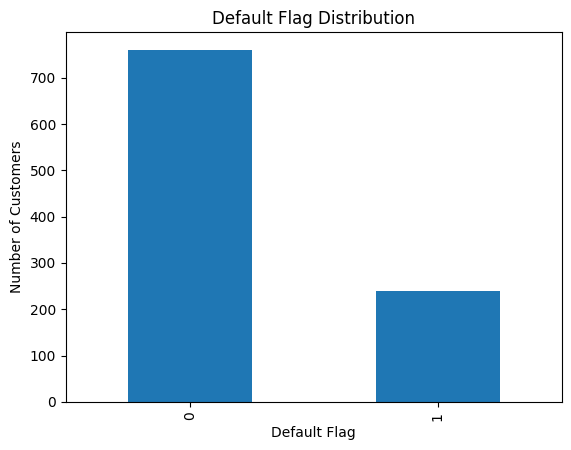

In [10]:
print(df["default_flag"].value_counts())

df["default_flag"].value_counts().plot(
    kind="bar"
)

plt.title("Default Flag Distribution")
plt.xlabel("Default Flag")
plt.ylabel("Number of Customers")

plt.show()

# Missing Value Handling

Missing values can affect the quality and accuracy of data analysis and machine learning models.

In this project, the following missing value handling techniques are demonstrated:

1. Simple Imputer
2. Most Frequent Imputation
3. Missing Indicator
4. Random Sample Imputation
5. KNN Imputer
6. MICE / Iterative Imputer
7. Complete Case Analysis

In [11]:
numeric_cols = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

categorical_cols = [
    "gender",
    "region",
    "education_level",
    "employment_type",
    "loan_purpose"
]

## 1. Simple Imputer

Simple Imputer replaces missing values using a selected strategy.

For numerical columns, the median is used because it is less affected by outliers.

For categorical columns, the most frequent value is used.

In [12]:
from sklearn.impute import SimpleImputer

simple_df = df.copy()

# Numerical Imputation using Median
num_imputer = SimpleImputer(strategy="median")

simple_df[numeric_cols] = num_imputer.fit_transform(
    simple_df[numeric_cols]
)

# Categorical Imputation using Most Frequent Value
cat_imputer = SimpleImputer(strategy="most_frequent")

simple_df[categorical_cols] = cat_imputer.fit_transform(
    simple_df[categorical_cols]
)

print("Missing values after Simple Imputation:")
print(simple_df.isnull().sum())

Missing values after Simple Imputation:
customer_id          0
age                  0
gender               0
region               0
education_level      0
employment_type      0
annual_income        0
loan_amount          0
loan_purpose         0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
join_date            0
default_flag         0
dtype: int64


## 2. Most Frequent Category Imputation

For categorical variables, missing values can be replaced with the category that occurs most frequently.

This method is useful when the missing percentage is relatively small.

In [13]:
most_frequent_df = df.copy()

for col in categorical_cols:
    most_frequent_value = most_frequent_df[col].mode()[0]
    
    most_frequent_df[col] = most_frequent_df[col].fillna(
        most_frequent_value
    )

print("Missing values in categorical columns:")
print(most_frequent_df[categorical_cols].isnull().sum())

Missing values in categorical columns:
gender             0
region             0
education_level    0
employment_type    0
loan_purpose       0
dtype: int64


## 3. Missing Indicator and Random Sample Imputation

A Missing Indicator creates a new column that records whether the original value was missing.

Random Sample Imputation replaces missing values by randomly selecting values from the existing non-missing observations.

In [14]:
random_df = df.copy()

columns_for_random_imputation = [
    "annual_income",
    "credit_score"
]

for col in columns_for_random_imputation:
    
    # Create Missing Indicator
    random_df[col + "_missing"] = random_df[col].isnull().astype(int)
    
    # Get available values
    available_values = random_df.loc[
        random_df[col].notnull(),
        col
    ]
    
    # Count missing values
    missing_count = random_df[col].isnull().sum()
    
    # Generate random replacement values
    random_values = np.random.choice(
        available_values,
        size=missing_count,
        replace=True
    )
    
    # Replace missing values
    random_df.loc[
        random_df[col].isnull(),
        col
    ] = random_values

print(
    random_df[
        [
            "annual_income_missing",
            "credit_score_missing"
        ]
    ].sum()
)

annual_income_missing    60
credit_score_missing     50
dtype: int64


## 4. KNN Imputer

KNN Imputer uses the values of similar observations to estimate missing values.

The method identifies nearby records based on available numerical features and uses their information for imputation.

In [15]:
from sklearn.impute import KNNImputer

knn_df = df.copy()

knn_imputer = KNNImputer(
    n_neighbors=5
)

knn_df[numeric_cols] = knn_imputer.fit_transform(
    knn_df[numeric_cols]
)

print("Missing values after KNN Imputation:")
print(knn_df[numeric_cols].isnull().sum())

Missing values after KNN Imputation:
age                  0
annual_income        0
loan_amount          0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
dtype: int64


## 5. MICE / Iterative Imputer

MICE stands for Multiple Imputation by Chained Equations.

The Iterative Imputer estimates missing values by using relationships between different features. It repeatedly predicts missing values until the estimates become stable.

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_df = df.copy()

mice_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

mice_df[numeric_cols] = mice_imputer.fit_transform(
    mice_df[numeric_cols]
)

print("Missing values after MICE Imputation:")
print(mice_df[numeric_cols].isnull().sum())

Missing values after MICE Imputation:
age                  0
annual_income        0
loan_amount          0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
dtype: int64


## 6. Complete Case Analysis

Complete Case Analysis removes rows containing missing values.

This method is simple but may reduce the size of the dataset. Therefore, it should only be used when the number of missing records is small.

In [17]:
complete_case_df = df.dropna().copy()

print("Original Dataset Shape:", df.shape)

print(
    "Dataset Shape After Complete Case Analysis:",
    complete_case_df.shape
)

print(
    "Rows Removed:",
    len(df) - len(complete_case_df)
)

Original Dataset Shape: (1000, 15)
Dataset Shape After Complete Case Analysis: (790, 15)
Rows Removed: 210


## 1. Univariate Analysis

Univariate analysis examines one variable at a time.

The first analysis examines the distribution of customer age.

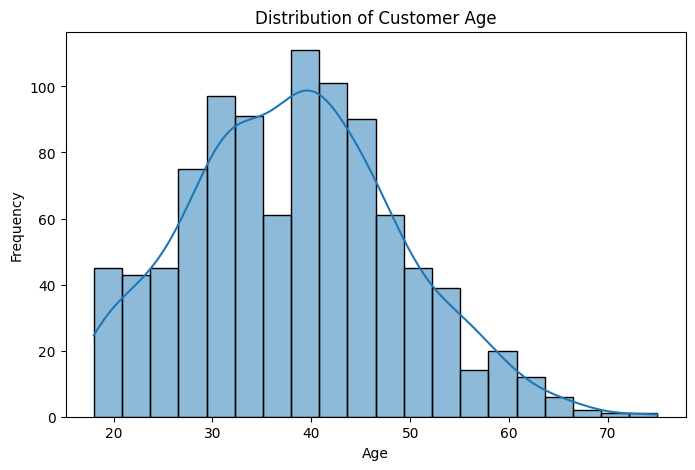

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Graph Interpretation

The histogram shows how customer ages are distributed in the dataset.

We can identify the age range where most customers are concentrated and determine whether the distribution is approximately symmetric or skewed. This helps us understand the demographic composition of the dataset.

Any unusually low or high age values may require further investigation during the data cleaning process.

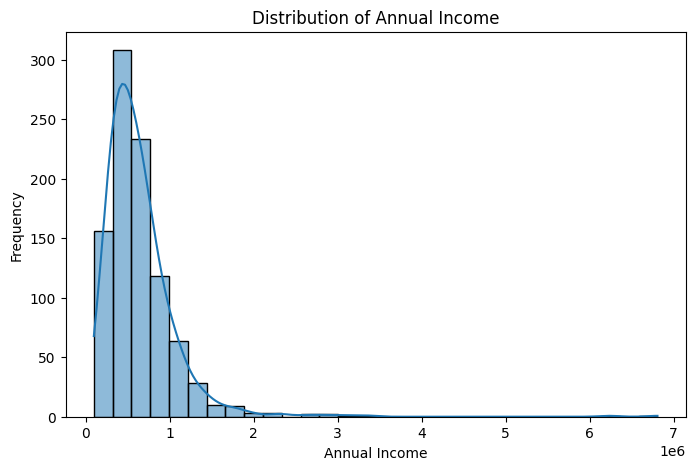

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="annual_income",
    bins=30,
    kde=True
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

### Graph Interpretation

The graph shows the distribution of annual income among customers.

The distribution helps identify whether income values are concentrated around a particular range or spread across multiple ranges. If the distribution is right-skewed, it indicates that a small number of customers have relatively high incomes compared with the majority.

This observation is useful when selecting suitable transformation and scaling techniques.

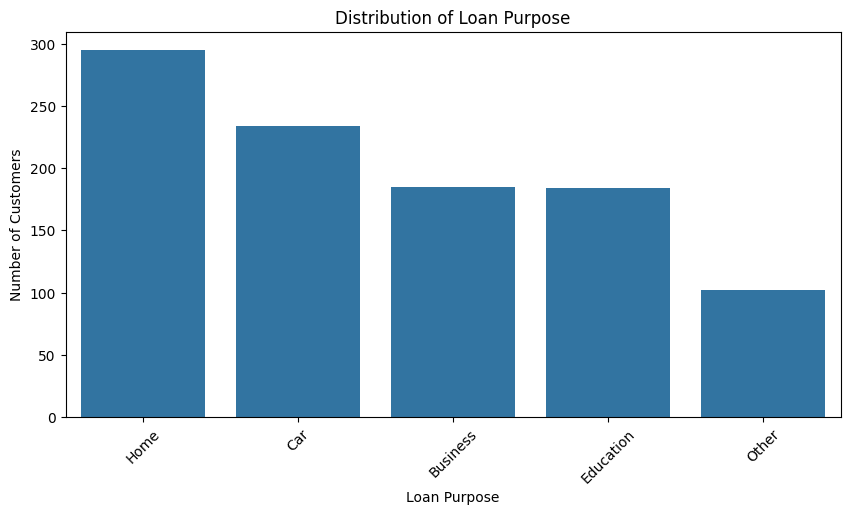

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="loan_purpose",
    order=df["loan_purpose"].value_counts().index
)

plt.title("Distribution of Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

### Graph Interpretation

This count plot shows the number of customers associated with each loan purpose.

The categories with taller bars represent more frequently occurring loan purposes. This analysis helps identify the most common reasons customers apply for loans.

The differences in category frequencies may also be important when performing categorical encoding and future machine learning analysis.

## 2. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

The following visualizations analyze relationships between numerical variables and between categorical and numerical variables.

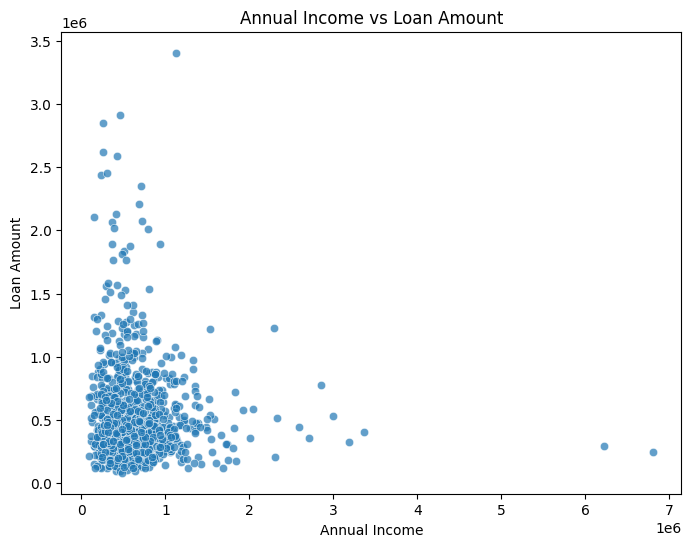

In [21]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="loan_amount",
    alpha=0.7
)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.show()

### Graph Interpretation

The scatter plot shows the relationship between annual income and loan amount.

Each point represents one customer. The graph helps determine whether customers with higher annual income generally take larger loan amounts.

An upward pattern would indicate a positive relationship, while a scattered pattern would suggest that annual income alone does not strongly determine the loan amount.

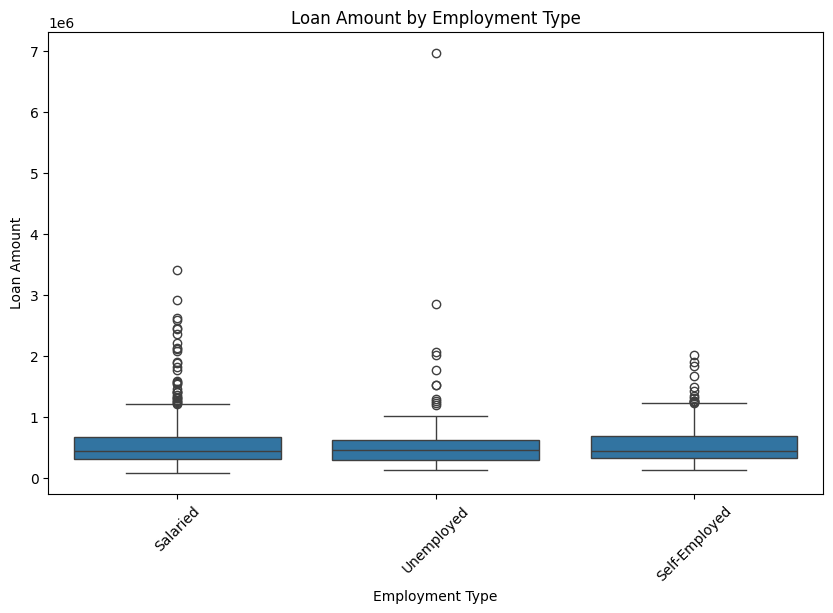

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="employment_type",
    y="loan_amount"
)

plt.title("Loan Amount by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Loan Amount")

plt.xticks(rotation=45)

plt.show()

### Graph Interpretation

The boxplot compares the distribution of loan amounts across different employment types.

The middle line inside each box represents the median loan amount, while the spread of the box shows the variability in loan amounts.

Points outside the whiskers may represent potential outliers. This graph helps determine whether employment type is associated with differences in borrowing behavior.

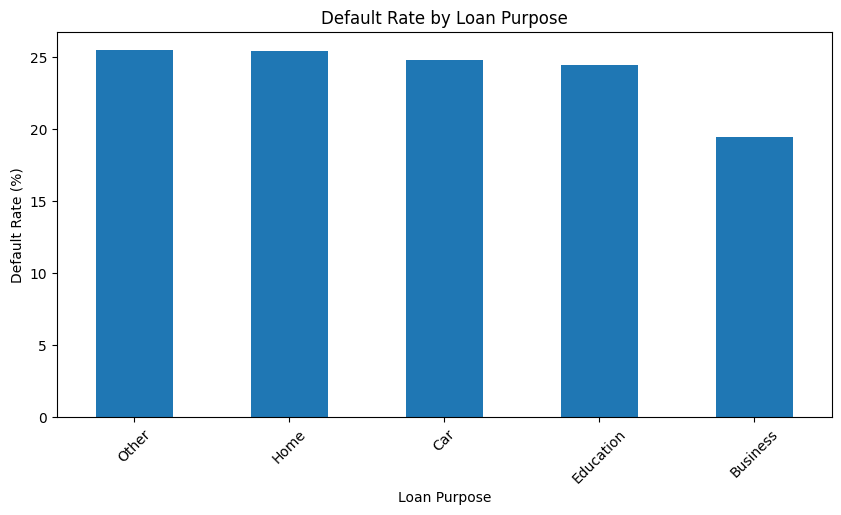

In [23]:
default_rate = (
    df.groupby("loan_purpose")["default_flag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10, 5))

default_rate.plot(
    kind="bar"
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Graph Interpretation

This chart compares the percentage of customers who defaulted across different loan purposes.

A higher bar indicates a higher default rate for that particular loan category.

This suggests that loan purpose may contain useful predictive information for the machine learning model and should be considered during feature encoding.

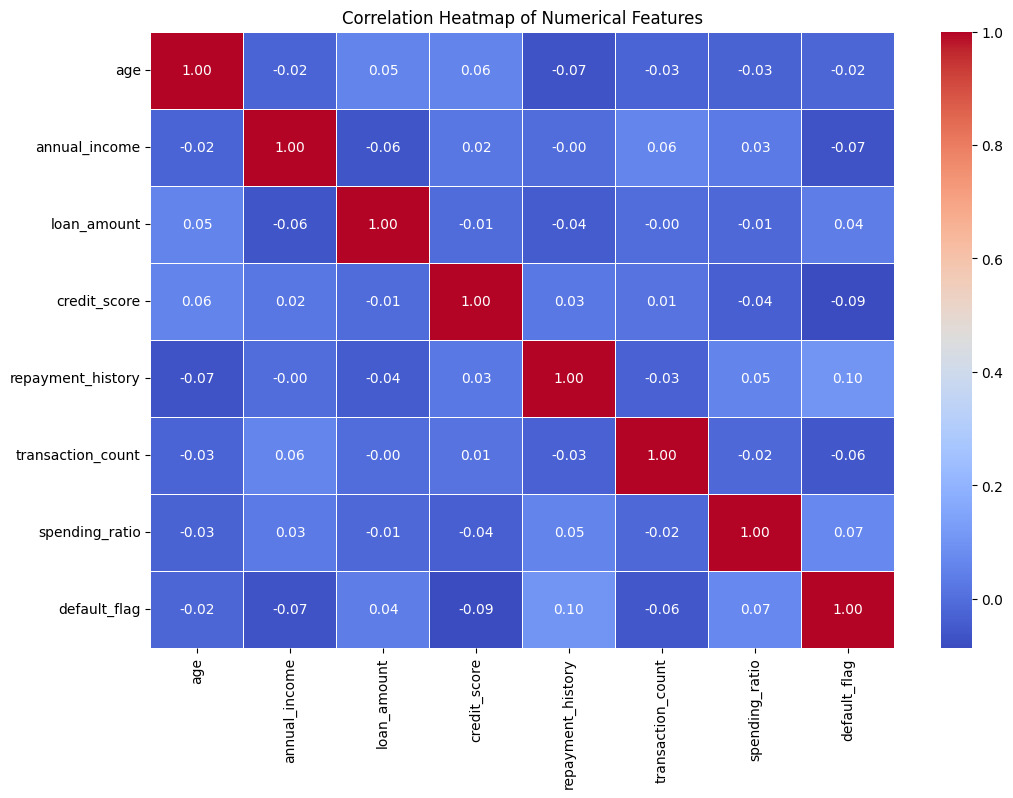

In [24]:
corr_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio",
    "default_flag"
]

correlation_matrix = df[corr_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Graph Interpretation

The correlation heatmap shows the strength and direction of relationships between numerical variables.

Correlation values close to 1 indicate a strong positive relationship, while values close to -1 indicate a strong negative relationship.

Values close to 0 indicate a weak linear relationship.

The heatmap is useful for identifying related features and understanding which variables may have stronger relationships with the target variable, `default_flag`.

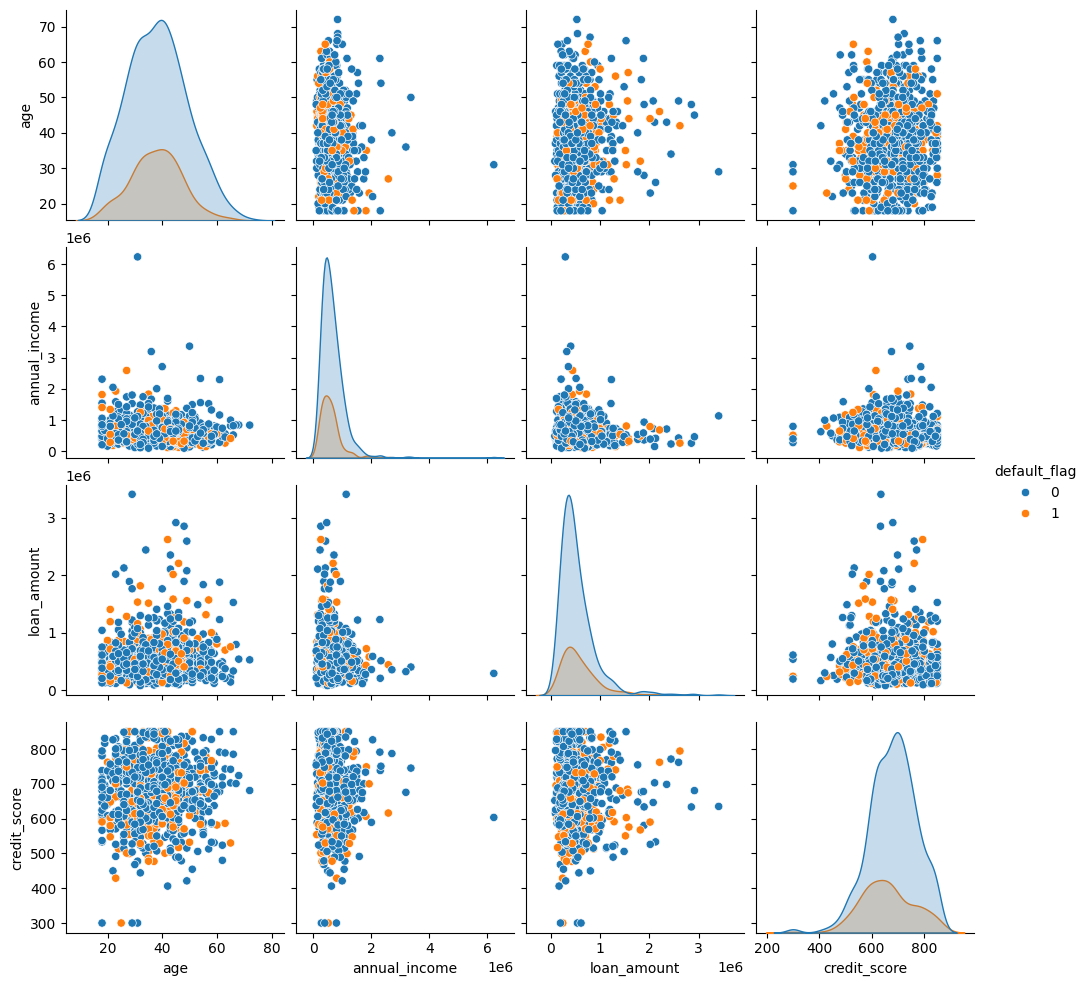

In [25]:
pairplot_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "default_flag"
]

sns.pairplot(
    df[pairplot_columns].dropna(),
    hue="default_flag"
)

plt.show()

### Graph Interpretation

The pair plot provides multiple visual comparisons between numerical variables.

The diagonal plots show the distribution of each feature, while the scatter plots show relationships between pairs of features.

Using `default_flag` as the color category helps identify whether customers who defaulted and customers who did not default show different patterns in age, income, loan amount and credit score.

This visualization helps identify potential features that may be useful for predicting customer default.

## Missing Value Handling Conclusion

Different imputation techniques were applied and demonstrated.

For the final preprocessing workflow:

- Numerical missing values will be handled using Median Imputation.
- Categorical missing values will be handled using Most Frequent Imputation.
- Missing Indicators are demonstrated to preserve information about missingness.
- KNN and MICE are demonstrated as advanced imputation techniques.
- Complete Case Analysis is used only for comparison.

# Part D: Outlier Handling

Outliers are extreme observations that are significantly different from most other values in the dataset.

Outliers can affect statistical analysis and machine learning models.

The following techniques are used:

1. Z-Score Method
2. IQR Method
3. Percentile Method
4. Winsorization Technique

In [26]:
clean_df = df.copy()

# Fill numerical missing values with median
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].median()
    )

# Fill categorical missing values with mode
for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].mode()[0]
    )

print("Total Missing Values:", clean_df.isnull().sum().sum())

Total Missing Values: 0


## 1. Z-Score Method

The Z-Score method measures how many standard deviations a value is away from the mean.

Generally, values with an absolute Z-Score greater than 3 are considered possible outliers.

In [27]:
from scipy import stats

outlier_cols = [
    "annual_income",
    "loan_amount",
    "credit_score"
]

z_scores = np.abs(
    stats.zscore(
        clean_df[outlier_cols]
    )
)

zscore_outliers = (
    z_scores > 3
)

print("Number of Z-Score Outliers:")

for i, col in enumerate(outlier_cols):
    print(
        col,
        ":",
        zscore_outliers[:, i].sum()
    )

Number of Z-Score Outliers:
annual_income : 12
loan_amount : 19
credit_score : 5


## 2. IQR Method

The Interquartile Range method identifies outliers using the first quartile and third quartile.

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [28]:
for col in outlier_cols:
    
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = clean_df[
        (clean_df[col] < lower_bound) |
        (clean_df[col] > upper_bound)
    ]
    
    print(
        col,
        "Outliers:",
        len(outliers)
    )

annual_income Outliers: 50
loan_amount Outliers: 55
credit_score Outliers: 7


## 3. Percentile Method

The Percentile Method detects extreme observations by defining lower and upper percentile limits.

In this project, the 1st percentile and 99th percentile are used as limits.

In [29]:
percentile_df = clean_df.copy()

for col in outlier_cols:
    
    lower_limit = percentile_df[col].quantile(0.01)
    upper_limit = percentile_df[col].quantile(0.99)
    
    percentile_df[col] = percentile_df[col].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Percentile-based outlier treatment completed.")

Percentile-based outlier treatment completed.


## 4. Winsorization Technique

Winsorization reduces the effect of extreme values by replacing them with values at selected percentile boundaries.

This allows us to retain all rows while reducing the influence of extreme observations.

In [30]:
winsorized_df = clean_df.copy()

for col in outlier_cols:
    
    lower_limit = winsorized_df[col].quantile(0.01)
    upper_limit = winsorized_df[col].quantile(0.99)
    
    winsorized_df[col] = winsorized_df[col].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Winsorization completed.")

winsorized_df[outlier_cols].describe()

Winsorization completed.


,annual_income,loan_amount,credit_score
count,1.000000e+03,1.000000e+03,1000.000000
mean,6.248269e+05,5.386801e+05,677.352350
std,3.590577e+05,3.630955e+05,86.663887
min,1.447512e+05,1.206118e+05,467.965000
25%,3.887794e+05,3.032550e+05,617.925000
50%,5.482611e+05,4.425727e+05,677.500000
75%,7.585635e+05,6.665568e+05,738.400000
max,2.294425e+06,2.126793e+06,850.000000


## Outlier Handling Conclusion

Outliers were identified using Z-Score and IQR methods.

Percentile clipping and Winsorization were used to reduce the effect of extreme values.

For the final preprocessing workflow, the cleaned and outlier-treated dataset will be used for feature engineering and transformation.

# Part E: Feature Engineering

Feature Engineering is the process of creating, transforming and selecting useful features from existing data.

In this section, the following tasks are performed:

1. Handle Mixed Variable Types
2. Extract Date and Time Features
3. Encode Categorical Variables
4. Encode Numerical Features
5. Prepare features for Machine Learning

In [31]:
work_df = winsorized_df.copy()

print("Working Dataset Shape:", work_df.shape)

work_df.head()

Working Dataset Shape: (1000, 15)


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,100001,43.0,Male,South,Primary,Salaried,710040.28,2.126793e+06,Other,698.6,3,27,23.03,2019-06-09,0
1,100002,36.0,Male,West,Graduate,Salaried,406309.31,3.746084e+05,Car,789.6,2,24,5.64,2020-11-13,0
2,100003,45.0,Female,East,Post-Graduate,Salaried,654528.65,6.977236e+05,Business,668.7,2,24,44.98,2021-09-10,0
3,100004,55.0,Female,West,Secondary,Salaried,337995.13,3.045550e+05,Car,567.7,1,26,10.32,2023-09-13,0
4,100005,35.0,Male,West,Graduate,Salaried,607591.50,1.283891e+05,Education,850.0,0,25,7.21,2018-09-04,0


## 1. Date and Time Feature Engineering

The `join_date` column contains the date when the customer joined the bank.

New features will be extracted:

- Join Year
- Join Month
- Join Day
- Join Weekday

In [32]:
work_df["join_date"] = pd.to_datetime(
    work_df["join_date"]
)

work_df["join_year"] = work_df["join_date"].dt.year

work_df["join_month"] = work_df["join_date"].dt.month

work_df["join_day"] = work_df["join_date"].dt.day

work_df["join_weekday"] = work_df["join_date"].dt.weekday

work_df[
    [
        "join_date",
        "join_year",
        "join_month",
        "join_day",
        "join_weekday"
    ]
].head()

,join_date,join_year,join_month,join_day,join_weekday
0,2019-06-09,2019,6,9,6
1,2020-11-13,2020,11,13,4
2,2021-09-10,2021,9,10,4
3,2023-09-13,2023,9,13,2
4,2018-09-04,2018,9,4,1


## 2. Ordinal Encoding

Ordinal Encoding is used when categories have a meaningful order.

The `education_level` variable has the following order:

Primary → Secondary → Graduate → Post-Graduate

In [33]:
from sklearn.preprocessing import OrdinalEncoder

education_order = [
    [
        "Primary",
        "Secondary",
        "Graduate",
        "Post-Graduate"
    ]
]

ordinal_encoder = OrdinalEncoder(
    categories=education_order
)

work_df["education_level_ordinal"] = ordinal_encoder.fit_transform(
    work_df[["education_level"]]
)

work_df[
    [
        "education_level",
        "education_level_ordinal"
    ]
].head()

,education_level,education_level_ordinal
0,Primary,0.0
1,Graduate,2.0
2,Post-Graduate,3.0
3,Secondary,1.0
4,Graduate,2.0


## 3. Label Encoding

Label Encoding converts categories into numerical values.

In this project, Label Encoding is demonstrated using the `gender` column.

In [34]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

work_df["gender_label"] = label_encoder.fit_transform(
    work_df["gender"]
)

print(
    work_df[
        [
            "gender",
            "gender_label"
        ]
    ].head()
)

   gender  gender_label
0    Male             1
1    Male             1
2  Female             0
3  Female             0
4    Male             1


## 4. One-Hot Encoding

One-Hot Encoding is used for categorical variables where there is no natural order.

In this project, it is applied to:

- Region
- Loan Purpose

In [35]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_data = onehot_encoder.fit_transform(
    work_df[
        [
            "region",
            "loan_purpose"
        ]
    ]
)

encoded_columns = onehot_encoder.get_feature_names_out(
    [
        "region",
        "loan_purpose"
    ]
)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=work_df.index
)

work_df = pd.concat(
    [
        work_df,
        encoded_df
    ],
    axis=1
)

print("One-Hot Encoding Completed.")

work_df.head()

One-Hot Encoding Completed.


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,gender_label,region_East,region_North,region_South,region_West,loan_purpose_Business,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other
0,100001,43.0,Male,South,Primary,Salaried,710040.28,2.126793e+06,Other,698.6,...,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100002,36.0,Male,West,Graduate,Salaried,406309.31,3.746084e+05,Car,789.6,...,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,100003,45.0,Female,East,Post-Graduate,Salaried,654528.65,6.977236e+05,Business,668.7,...,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,100004,55.0,Female,West,Secondary,Salaried,337995.13,3.045550e+05,Car,567.7,...,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,100005,35.0,Male,West,Graduate,Salaried,607591.50,1.283891e+05,Education,850.0,...,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## 5. Binning and Discretization

Binning converts continuous numerical values into groups.

The following methods are demonstrated:

1. Equal Width Binning
2. Binarization
3. Quantile Binning
4. K-Means Binning

In [36]:
work_df["income_bin"] = pd.cut(
    work_df["annual_income"],
    bins=4,
    labels=False
)

work_df[
    [
        "annual_income",
        "income_bin"
    ]
].head()

,annual_income,income_bin
0,710040.28,1
1,406309.31,0
2,654528.65,0
3,337995.13,0
4,607591.50,0


## Binarization

Binarization converts numerical values into 0 and 1 based on a selected threshold.

In this example:

- Income less than or equal to ₹7,00,000 = 0
- Income greater than ₹7,00,000 = 1

In [37]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(
    threshold=700000
)

work_df["high_income_flag"] = binarizer.fit_transform(
    work_df[["annual_income"]]
)

work_df[
    [
        "annual_income",
        "high_income_flag"
    ]
].head()

,annual_income,high_income_flag
0,710040.28,1.0
1,406309.31,0.0
2,654528.65,0.0
3,337995.13,0.0
4,607591.50,0.0


## Quantile Binning

Quantile Binning divides data into groups containing approximately equal numbers of observations.

It is applied to the `transaction_count` feature.

In [38]:
work_df["transaction_quantile_bin"] = pd.qcut(
    work_df["transaction_count"],
    q=4,
    labels=False,
    duplicates="drop"
)

work_df[
    [
        "transaction_count",
        "transaction_quantile_bin"
    ]
].head()

,transaction_count,transaction_quantile_bin
0,27,2
1,24,1
2,24,1
3,26,2
4,25,1


## K-Means Binning

K-Means clustering can also be used to group numerical values into clusters.

Here, transaction counts are divided into four groups using K-Means.

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

work_df["transaction_kmeans_bin"] = kmeans.fit_predict(
    work_df[
        [
            "transaction_count"
        ]
    ]
)

work_df[
    [
        "transaction_count",
        "transaction_kmeans_bin"
    ]
].head()

,transaction_count,transaction_kmeans_bin
0,27,2
1,24,1
2,24,1
3,26,2
4,25,1


# Part F: Feature Scaling

Feature Scaling transforms numerical variables so that they are on comparable scales.

The following scaling methods are demonstrated:

1. Standardization
2. Normalization
3. Min-Max Scaling
4. MaxAbs Scaling
5. Robust Scaling

In [40]:
scale_cols = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

work_df[scale_cols].head()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,43.0,710040.28,2.126793e+06,698.6,3,27,23.03
1,36.0,406309.31,3.746084e+05,789.6,2,24,5.64
2,45.0,654528.65,6.977236e+05,668.7,2,24,44.98
3,55.0,337995.13,3.045550e+05,567.7,1,26,10.32
4,35.0,607591.50,1.283891e+05,850.0,0,25,7.21


## 1. Standardization

Standardization transforms data so that it has:

- Mean approximately equal to 0
- Standard deviation approximately equal to 1

It is also called Z-Score Scaling.

In [41]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(
        work_df[scale_cols]
    ),
    columns=[
        col + "_standard"
        for col in scale_cols
    ],
    index=work_df.index
)

standard_scaled.head()

,age_standard,annual_income_standard,loan_amount_standard,credit_score_standard,repayment_history_standard,transaction_count_standard,spending_ratio_standard
0,0.461030,0.237444,4.376004,0.245296,0.694905,0.418341,-0.517976
1,-0.212850,-0.608891,-0.452095,1.295855,0.000694,-0.180429,-1.654721
2,0.653567,0.082763,0.438240,-0.099888,0.000694,-0.180429,0.916846
3,1.616252,-0.799246,-0.645126,-1.265893,-0.693516,0.218751,-1.348800
4,-0.309118,-0.048026,-1.130546,1.993149,-1.387726,0.019161,-1.552094


## 2. Normalization

Normalization scales each observation based on its vector length.

It is useful when comparing observations based on relative values.

In [42]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

normalized_data = normalizer.fit_transform(
    work_df[scale_cols]
)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=[
        col + "_normalized"
        for col in scale_cols
    ],
    index=work_df.index
)

normalized_df.head()

,age_normalized,annual_income_normalized,loan_amount_normalized,credit_score_normalized,repayment_history_normalized,transaction_count_normalized,spending_ratio_normalized
0,0.000019,0.316673,0.948535,0.000312,0.000001,0.000012,0.000010
1,0.000065,0.735205,0.677843,0.001429,0.000004,0.000043,0.000010
2,0.000047,0.684171,0.729322,0.000699,0.000002,0.000025,0.000047
3,0.000121,0.742901,0.669401,0.001248,0.000002,0.000057,0.000023
4,0.000056,0.978394,0.206743,0.001369,0.000000,0.000040,0.000012


## 3. Min-Max Scaling

Min-Max Scaling transforms values into a selected range.

The most common range is:

0 to 1

In [43]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(
        work_df[scale_cols]
    ),
    columns=[
        col + "_minmax"
        for col in scale_cols
    ],
    index=work_df.index
)

minmax_scaled.head()

,age_minmax,annual_income_minmax,loan_amount_minmax,credit_score_minmax,repayment_history_minmax,transaction_count_minmax,spending_ratio_minmax
0,0.438596,0.262965,1.000000,0.603701,0.375,0.548387,0.249374
1,0.315789,0.121673,0.126607,0.841899,0.250,0.451613,0.031563
2,0.473684,0.237142,0.287667,0.525436,0.250,0.451613,0.524299
3,0.649123,0.089895,0.091688,0.261062,0.125,0.516129,0.090180
4,0.298246,0.215307,0.003877,1.000000,0.000,0.483871,0.051227


## 4. MaxAbs Scaling

MaxAbs Scaling divides each feature by its maximum absolute value.

The values are generally transformed into the range between -1 and 1.

In [44]:
from sklearn.preprocessing import MaxAbsScaler

maxabs_scaler = MaxAbsScaler()

maxabs_scaled = pd.DataFrame(
    maxabs_scaler.fit_transform(
        work_df[scale_cols]
    ),
    columns=[
        col + "_maxabs"
        for col in scale_cols
    ],
    index=work_df.index
)

maxabs_scaled.head()

,age_maxabs,annual_income_maxabs,loan_amount_maxabs,credit_score_maxabs,repayment_history_maxabs,transaction_count_maxabs,spending_ratio_maxabs
0,0.573333,0.309463,1.000000,0.821882,0.375,0.658537,0.277604
1,0.480000,0.177085,0.176138,0.928941,0.250,0.585366,0.067985
2,0.600000,0.285269,0.328064,0.786706,0.250,0.585366,0.542189
3,0.733333,0.147311,0.143199,0.667882,0.125,0.634146,0.124397
4,0.466667,0.264812,0.060367,1.000000,0.000,0.609756,0.086909


## 5. Robust Scaling

Robust Scaling uses the median and Interquartile Range.

It is useful when the dataset contains outliers because it is less affected by extreme values.

In [45]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

robust_scaled = pd.DataFrame(
    robust_scaler.fit_transform(
        work_df[scale_cols]
    ),
    columns=[
        col + "_robust"
        for col in scale_cols
    ],
    index=work_df.index
)

robust_scaled.head()

,age_robust,annual_income_robust,loan_amount_robust,credit_score_robust,repayment_history_robust,transaction_count_robust,spending_ratio_robust
0,0.357143,0.437496,4.635871,0.175140,0.5,0.285714,-0.297702
1,-0.142857,-0.383878,-0.187074,0.930484,0.0,-0.142857,-1.092946
2,0.500000,0.287377,0.702311,-0.073044,0.0,-0.142857,0.706071
3,1.214286,-0.568618,-0.379898,-0.911392,-0.5,0.142857,-0.878930
4,-0.214286,0.160446,-0.864800,1.431832,-1.0,0.000000,-1.021150


# Part G: Feature Construction and Transformation

Feature construction creates new useful features from existing columns.

Feature transformation changes the distribution of numerical variables to make them more suitable for analysis and machine learning.

In this section, the following transformations are performed:

1. Log Transformation
2. Reciprocal Transformation
3. Square Root Transformation
4. Box-Cox Transformation
5. Yeo-Johnson Transformation
6. ColumnTransformer

New features are also created from the existing dataset.

## 1. Feature Construction

The following new features will be created:

### Debt-to-Income Ratio

Debt-to-Income Ratio = Loan Amount / Annual Income

This feature shows the relationship between a customer's loan amount and annual income.

### Average Monthly Transactions

Average Monthly Transactions = Transaction Count / 6

The dataset contains transactions for the last 6 months.

### Spending-to-Income Ratio

The spending ratio is converted into a decimal value for easier use in machine learning.

In [46]:
# Create Debt-to-Income Ratio
work_df["debt_to_income_ratio"] = (
    work_df["loan_amount"] /
    work_df["annual_income"].replace(0, np.nan)
)

# Create Average Monthly Transactions
work_df["avg_monthly_transactions"] = (
    work_df["transaction_count"] / 6
)

# Create Spending-to-Income Ratio
work_df["spending_to_income_ratio"] = (
    work_df["spending_ratio"] / 100
)

# Check the new features
work_df[
    [
        "loan_amount",
        "annual_income",
        "debt_to_income_ratio",
        "transaction_count",
        "avg_monthly_transactions",
        "spending_ratio",
        "spending_to_income_ratio"
    ]
].head()

,loan_amount,annual_income,debt_to_income_ratio,transaction_count,avg_monthly_transactions,spending_ratio,spending_to_income_ratio
0,2.126793e+06,710040.28,2.995314,27,4.500000,23.03,0.2303
1,3.746084e+05,406309.31,0.921978,24,4.000000,5.64,0.0564
2,6.977236e+05,654528.65,1.065994,24,4.000000,44.98,0.4498
3,3.045550e+05,337995.13,0.901063,26,4.333333,10.32,0.1032
4,1.283891e+05,607591.50,0.211308,25,4.166667,7.21,0.0721


## 2. FunctionTransformer

FunctionTransformer allows us to apply custom mathematical functions to features.

In this project, it is used to demonstrate a Log Transformation.

In [47]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(
    np.log1p
)

transformed_data = log_transformer.fit_transform(
    work_df[["spending_ratio"]]
)

work_df["spending_ratio_log"] = transformed_data.iloc[:, 0]

work_df[
    [
        "spending_ratio",
        "spending_ratio_log"
    ]
].head()

,spending_ratio,spending_ratio_log
0,23.03,3.179303
1,5.64,1.893112
2,44.98,3.828207
3,10.32,2.426571
4,7.21,2.105353


## 3. Reciprocal Transformation

Reciprocal Transformation changes a value using the following formula:

1 / (x + 1)

Adding 1 prevents division by zero.

In [48]:
work_df["spending_ratio_reciprocal"] = (
    1 / (work_df["spending_ratio"] + 1)
)

work_df[
    [
        "spending_ratio",
        "spending_ratio_reciprocal"
    ]
].head()

,spending_ratio,spending_ratio_reciprocal
0,23.03,0.041615
1,5.64,0.150602
2,44.98,0.021749
3,10.32,0.088339
4,7.21,0.121803


## 4. Square Root Transformation

Square Root Transformation is useful for reducing the effect of positive skewness in numerical data.

In [49]:
work_df["spending_ratio_sqrt"] = np.sqrt(
    work_df["spending_ratio"]
)

work_df[
    [
        "spending_ratio",
        "spending_ratio_sqrt"
    ]
].head()

,spending_ratio,spending_ratio_sqrt
0,23.03,4.798958
1,5.64,2.374868
2,44.98,6.706713
3,10.32,3.212476
4,7.21,2.685144


## 5. Box-Cox Transformation

Box-Cox Transformation is used to transform positive numerical data toward a more normal distribution.

The feature used in this project is `loan_amount`.

In [50]:
from sklearn.preprocessing import PowerTransformer

boxcox_transformer = PowerTransformer(
    method="box-cox",
    standardize=False
)

work_df["loan_amount_boxcox"] = boxcox_transformer.fit_transform(
    work_df[["loan_amount"]]
).ravel()

work_df[
    [
        "loan_amount",
        "loan_amount_boxcox"
    ]
].head()

,loan_amount,loan_amount_boxcox
0,2.126793e+06,7.440928
1,3.746084e+05,7.031195
2,6.977236e+05,7.186642
3,3.045550e+05,6.977146
4,1.283891e+05,6.738457


## 6. Yeo-Johnson Transformation

Yeo-Johnson Transformation is similar to Box-Cox Transformation.

Unlike Box-Cox, Yeo-Johnson can also handle zero and negative values.

In [51]:
yeojohnson_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

work_df["annual_income_yeojohnson"] = (
    yeojohnson_transformer.fit_transform(
        work_df[["annual_income"]]
    ).ravel()
)

work_df[
    [
        "annual_income",
        "annual_income_yeojohnson"
    ]
].head()

,annual_income,annual_income_yeojohnson
0,710040.28,14.646118
1,406309.31,13.990209
2,654528.65,14.550184
3,337995.13,13.774886
4,607591.50,14.462576


## 7. ColumnTransformer

A ColumnTransformer allows different preprocessing methods to be applied to different groups of columns.

In this project:

- Numerical columns use Median Imputation and Robust Scaling.
- Categorical columns use Most Frequent Imputation and One-Hot Encoding.

This creates a complete preprocessing pipeline.

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler

In [53]:
final_df = work_df.copy()

# Remove original date column because date features were already extracted
final_df = final_df.drop(
    columns=["join_date"],
    errors="ignore"
)

print("Final DataFrame Shape:", final_df.shape)

final_df.head()

Final DataFrame Shape: (1000, 41)


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,transaction_quantile_bin,transaction_kmeans_bin,debt_to_income_ratio,avg_monthly_transactions,spending_to_income_ratio,spending_ratio_log,spending_ratio_reciprocal,spending_ratio_sqrt,loan_amount_boxcox,annual_income_yeojohnson
0,100001,43.0,Male,South,Primary,Salaried,710040.28,2.126793e+06,Other,698.6,...,2,2,2.995314,4.500000,0.2303,3.179303,0.041615,4.798958,7.440928,14.646118
1,100002,36.0,Male,West,Graduate,Salaried,406309.31,3.746084e+05,Car,789.6,...,1,1,0.921978,4.000000,0.0564,1.893112,0.150602,2.374868,7.031195,13.990209
2,100003,45.0,Female,East,Post-Graduate,Salaried,654528.65,6.977236e+05,Business,668.7,...,1,1,1.065994,4.000000,0.4498,3.828207,0.021749,6.706713,7.186642,14.550184
3,100004,55.0,Female,West,Secondary,Salaried,337995.13,3.045550e+05,Car,567.7,...,2,2,0.901063,4.333333,0.1032,2.426571,0.088339,3.212476,6.977146,13.774886
4,100005,35.0,Male,West,Graduate,Salaried,607591.50,1.283891e+05,Education,850.0,...,1,1,0.211308,4.166667,0.0721,2.105353,0.121803,2.685144,6.738457,14.462576


## Define Numerical and Categorical Features

The dataset is divided into numerical and categorical features so that separate preprocessing steps can be applied.

In [54]:
final_numeric_features = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio",
    "debt_to_income_ratio",
    "avg_monthly_transactions",
    "spending_to_income_ratio"
]

final_categorical_features = [
    "gender",
    "region",
    "education_level",
    "employment_type",
    "loan_purpose"
]

print("Numerical Features:")
print(final_numeric_features)

print("\nCategorical Features:")
print(final_categorical_features)

Numerical Features:
['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'debt_to_income_ratio', 'avg_monthly_transactions', 'spending_to_income_ratio']

Categorical Features:
['gender', 'region', 'education_level', 'employment_type', 'loan_purpose']


In [55]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            RobustScaler()
        )
    ]
)

In [56]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            final_numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            final_categorical_features
        )
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


# Part H: Final Cleaned and Transformed Dataset

The final preprocessing pipeline will now be applied to the selected features.

The output will contain:

- Missing values handled
- Numerical features scaled
- Categorical features encoded
- New engineered features
- Data ready for Machine Learning

In [58]:
X = final_df[
    final_numeric_features +
    final_categorical_features
].copy()

y = final_df["default_flag"].copy()

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 15)
Target Shape: (1000,)


In [59]:
final_matrix = preprocessor.fit_transform(X)

print(
    "Final Transformed Matrix Shape:",
    final_matrix.shape
)

Final Transformed Matrix Shape: (1000, 29)


In [60]:
feature_names = preprocessor.get_feature_names_out()

print("Total Final Features:", len(feature_names))

print("\nFirst 10 Feature Names:")

print(feature_names[:10])

Total Final Features: 29

First 10 Feature Names:
['num__age' 'num__annual_income' 'num__loan_amount' 'num__credit_score'
 'num__repayment_history' 'num__transaction_count' 'num__spending_ratio'
 'num__debt_to_income_ratio' 'num__avg_monthly_transactions'
 'num__spending_to_income_ratio']


In [61]:
if hasattr(final_matrix, "toarray"):
    
    final_matrix = final_matrix.toarray()

final_cleaned_df = pd.DataFrame(
    final_matrix,
    columns=feature_names
)

# Add Target Variable
final_cleaned_df["default_flag"] = (
    y.reset_index(drop=True)
)

print(
    "Final Cleaned Dataset Shape:",
    final_cleaned_df.shape
)

final_cleaned_df.head()

Final Cleaned Dataset Shape: (1000, 30)


,num__age,num__annual_income,num__loan_amount,num__credit_score,num__repayment_history,num__transaction_count,num__spending_ratio,num__debt_to_income_ratio,num__avg_monthly_transactions,num__spending_to_income_ratio,...,cat__education_level_Secondary,cat__employment_type_Salaried,cat__employment_type_Self-Employed,cat__employment_type_Unemployed,cat__loan_purpose_Business,cat__loan_purpose_Car,cat__loan_purpose_Education,cat__loan_purpose_Home,cat__loan_purpose_Other,default_flag
0,0.357143,0.437496,4.635871,0.175140,0.5,0.285714,-0.297702,2.273781,0.285714,-0.297702,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.142857,-0.383878,-0.187074,0.930484,0.0,-0.142857,-1.092946,0.119237,-0.142857,-1.092946,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2,0.500000,0.287377,0.702311,-0.073044,0.0,-0.142857,0.706071,0.268893,-0.142857,0.706071,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,1.214286,-0.568618,-0.379898,-0.911392,-0.5,0.142857,-0.878930,0.097503,0.142857,-0.878930,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,-0.214286,0.160446,-0.864800,1.431832,-1.0,0.000000,-1.021150,-0.619269,0.000000,-1.021150,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


## Save Final Cleaned Dataset

The final cleaned and transformed dataset is exported as a CSV file.

This dataset is now ready to be used for Machine Learning modeling.

In [62]:
final_cleaned_df.to_csv(
    "final_cleaned_customer_credit_risk_dataset.csv",
    index=False
)

print(
    "Final cleaned dataset saved successfully."
)

print(
    "File Name: final_cleaned_customer_credit_risk_dataset.csv"
)

Final cleaned dataset saved successfully.
File Name: final_cleaned_customer_credit_risk_dataset.csv


# Final Dataset Validation

Before completing the project, the final dataset is checked for:

1. Missing Values
2. Duplicate Rows
3. Dataset Shape
4. Target Variable Distribution

These checks confirm that the dataset is ready for Machine Learning.

In [63]:
print(
    "Total Missing Values:",
    final_cleaned_df.isnull().sum().sum()
)   

Total Missing Values: 0


In [64]:
print(
    "Duplicate Rows:",
    final_cleaned_df.duplicated().sum()
)

Duplicate Rows: 0


In [65]:
print(
    "Final Dataset Shape:",
    final_cleaned_df.shape
)

print(
    "\nTotal Features:",
    final_cleaned_df.shape[1] - 1
)

print(
    "Total Records:",
    final_cleaned_df.shape[0]
)

Final Dataset Shape: (1000, 30)

Total Features: 29
Total Records: 1000


In [66]:
print(
    final_cleaned_df[
        "default_flag"
    ].value_counts()
)

print("\nPercentage Distribution:")

print(
    final_cleaned_df[
        "default_flag"
    ].value_counts(
        normalize=True
    ) * 100
)

default_flag
0    760
1    240
Name: count, dtype: int64

Percentage Distribution:
default_flag
0    76.0
1    24.0
Name: proportion, dtype: float64


# Final Project Report

## 1. Missing Value Strategies

Multiple missing value handling techniques were demonstrated, including Simple Imputation, Most Frequent Imputation, Missing Indicator with Random Sample Imputation, KNN Imputation, MICE / Iterative Imputation and Complete Case Analysis.

For the final pipeline, Median Imputation was used for numerical features and Most Frequent Imputation was used for categorical features.

---

## 2. Outlier Handling

Outliers were identified using Z-Score and IQR methods.

Percentile Clipping and Winsorization were applied to reduce the influence of extreme values while preserving the majority of records.

---

## 3. Encoding Methods

Different encoding methods were applied:

- Ordinal Encoding for education level
- Label Encoding for gender
- One-Hot Encoding for region and loan purpose
- Numerical encoding through binning, binarization, quantile binning and K-Means binning

---

## 4. Scaling and Transformations

The project demonstrated:

- Standardization
- Normalization
- Min-Max Scaling
- MaxAbs Scaling
- Robust Scaling

The following transformations were also applied:

- Log Transformation
- Reciprocal Transformation
- Square Root Transformation
- Box-Cox Transformation
- Yeo-Johnson Transformation

---

## 5. Newly Engineered Features

The following new features were created:

1. Debt-to-Income Ratio
2. Average Monthly Transactions
3. Spending-to-Income Ratio
4. Join Year
5. Join Month
6. Join Day
7. Join Weekday

These features provide additional useful information for Machine Learning models.

---

## 6. Final Dataset Readiness

The final dataset has been successfully cleaned and transformed.

The preprocessing workflow handled missing values, treated outliers, encoded categorical variables, scaled numerical variables and created new features.

The final dataset is ready for Machine Learning modeling.

In [67]:
print("=" * 60)

print("HOLISTIC DATA PREPARER - FINAL PROJECT COMPLETED")

print("=" * 60)

print(
    "\nOriginal Dataset Shape:",
    df.shape
)

print(
    "Final Dataset Shape:",
    final_cleaned_df.shape
)

print(
    "Final Missing Values:",
    final_cleaned_df.isnull().sum().sum()
)

print(
    "Final Duplicate Rows:",
    final_cleaned_df.duplicated().sum()
)

print(
    "\nStatus: Dataset is ready for Machine Learning."
)

print("=" * 60)

HOLISTIC DATA PREPARER - FINAL PROJECT COMPLETED

Original Dataset Shape: (1000, 15)
Final Dataset Shape: (1000, 30)
Final Missing Values: 0
Final Duplicate Rows: 0

Status: Dataset is ready for Machine Learning.
